# Two pipeline changes: border padding + a decoupled, smaller NMS radius

**Purpose.** [`tm_threshold_axis_sweep.ipynb`](tm_threshold_axis_sweep.ipynb) found that even
at the loosest `z` tested, full-list mitotic recall was below 1.0 on some domains (e.g.
`0.9724` on `301.tiff`, canine cutaneous mast cell tumour, at `z = -1.0`). Diagnosing *why*
(below) turned up two distinct, independent leaks, and this notebook fixes both, verifies the
fix is doing what it claims, and re-runs the full sweep to check whether every domain now
reaches full recall.

**Leak 1 -- unreachable border pixels.** `fused_response` marks a pixel `valid` only where
`cv2.matchTemplate` had a full window to correlate against -- a ~25 px margin
(`(BASE_SIZE-1)//2`) around every ROI edge is `valid=False` regardless of score. A mitotic
figure sitting in that margin can never produce a candidate, at any threshold. On
`301.tiff` **2** of 217 evaluation mitoses have a click pixel inside that margin, but only
**1** of them (ann 14779) is actually *missed* as a result -- the other (ann 15022) is still
claimed by a detection 25 px away, inside the 29.6 px match radius. Being unreachable at the
click pixel and being unfound are different things, and the leak accounting below is
**1 border + 5 NMS = 6**, which is what v1's `full_list_recall` (211/217 = 0.97235) and this
notebook's own recall delta (0.0276 x 217 = 6.0) both say. This is measured, not asserted:
see the diagnostic cell below.

**Leak 2 -- NMS suppressing a GT's own correct peak.** Diagnosed directly on `301.tiff`'s 5
other missed mitoses (traced through the actual NMS suppression order, not inferred): in every
one of them, the peak nearest the true click survived local-maximum extraction (4.5-10 px from
the annotation) but was then suppressed by NMS in favour of a competing peak 23-29 px away that
happened to score higher. That competing peak was, in every case, still closest to the *same*
annotation -- not a different one -- so this is not literally "two neighbouring ground-truth
points merged into one detection" (checked: the minimum real annotation-to-annotation spacing
across all 7 domain images is 36.8 px, above the ~30 px production NMS radius already). It is
the more subtle sibling of that problem the search reported to us: `TM_CCOEFF`'s correlation
surface around one object is not always sharply peaked at the true click centre, and the old
NMS radius (~30 px, tied to the *evaluation* match radius) was large enough to let an
off-centre secondary peak eat the on-centre one. Shrinking the NMS radius decouples "is this a
duplicate of the same detection" from "is this within tolerance of a ground-truth point" --
which were never the same question and had no reason to share one radius.

Both fixes, and why they don't just paper over a real gap, are verified below before the sweep
is re-run -- not assumed because they sound right.

> **Corrected 2026-09-04.** Audited in
> [`Research Logs/2026-09-03-tm-axis-sweep-audit.md`](Research%20Logs/2026-09-03-tm-axis-sweep-audit.md).
> Two corrections are load-bearing: the leak accounting above (was "2 stranded"), and the
> `chromatin_od` read-depth columns, which this notebook's own Fix 1 corrupted with border
> `NaN`s -- fixed in the main loop below, and the conclusion it invalidated rewritten.


In [1]:
import time
NB_T0 = time.time()

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from midog_utils import chromatin as cm
from midog_utils import channels as ch
from midog_utils import compare as cp
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import experiment as ex
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils.nms import nms_by_distance
from sklearn.neighbors import KDTree

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
print('imports ok')

imports ok


## Configuration

Everything from `tm_threshold_axis_sweep.ipynb` is unchanged (channel, method, template size,
seed rule, `z` sweep, budgets) so the two runs are comparable cell-for-cell. Two new
quantities:

* **`PAD`** -- computed from the actual template bank (`(template_size - 1) // 2`), not a
  hardcoded number, so it stays correct if `BASE_SIZE` or the augmentation scales ever change.
* **`NMS_RADIUS_UM`** -- a *separate* physical radius for de-duplication, distinct from
  `evaluate.MIDOG_RADIUS_UM` (7.5 um, the competition's own "close enough to count as found"
  tolerance used only for scoring). Reusing `evaluate.radius_px(mpp, radius_um=...)` keeps it
  defined the same physically-scaled way the eval radius already is, rather than a raw pixel
  constant that would mean a different physical distance on every scanner. `5.0` um was picked
  so the resulting pixel radius (19.7-22.1 px across these 7 domains -- computed below) sits
  comfortably under both the dataset's documented minimum true annotation spacing (26.2 px,
  `find_and_suppress.py`) and the 23-29 px same-object suppression gaps found in the `301.tiff`
  diagnostic, while staying well above `peak_min_distance=7` so genuinely-redundant peaks on
  one object are still merged.

**This deliberately breaks an existing invariant.** `compare.evaluate_arms` runs
`invariants.check_nms_radius`, which raises if `Arm.nms_radius != evaluate.radius_px(mpp)` --
exactly the assumption this notebook is intentionally overturning. Arms below are built with
`nms_radius=None` (skipping that specific check) rather than silently failing it; `NMS_RADIUS`
is still recorded in `extra` on every row for the audit trail.

**What that override costs, measured rather than waved at.** `invariants.py` names the exact
defect it was written to catch: *"a constant 25.0 px NMS radius let two detections 26 px apart
both survive while both sat inside one ground-truth object's match radius (29.6-33.1 px across
these scanners), inflating the FROC's false-positive axis with duplicates."* Decoupling the two
radii re-opens precisely that, and the cost is not only "more candidates to read": a second
detection on an already-claimed object is bucketed `non_human_findings`, i.e. counted as an
unannotated **false positive**. The main loop below counts them per domain. On `301.tiff` the
figure rises from **111** (v1, NMS at the match radius) to **281** -- about 1.1% of that pool's
false positives, so it distorts nothing headline, but it does feed `precision_full` in the first
notebook and `frac_fp_in_tp_range` in the largest-CC notebook, neither of which corrects for it.
The decoupling still stands; what was missing was this number.

**`CURRENT_Z = 0.5`** is `tm_variant_sweep.FLOOR_Z` / `premise_test.py`'s `med + 0.5*mad`, the
extraction-floor convention in force when this ran -- *not* `FSConfig.score_threshold = 0.5`,
which is a raw `TM_CCOEFF_NORMED` score that happens to share the number. The operating point
moved to `z = 1.0` afterwards, in `tp_fp_score_distribution.ipynb`; the value is left at 0.5 here
because the before/after snapshot below is taken at it.


In [2]:
CHANNEL = 'hematoxylin_od'
METHOD = cv2.TM_CCOEFF
BASE_SIZE = tm.BASE_SIZE
PEAK_MIN_DISTANCE = 7
SEED_INDEX = 0
SELF_HIT_RADIUS = 5.0

Z_LEVELS = (-1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0)
CURRENT_Z = 0.5
DEEP_FLOOR_Z = min(Z_LEVELS) - 0.5
MAX_PEAKS = 2_000_000

NMS_RADIUS_UM = 5.0                                     # new: de-dup radius, decoupled from eval
MATCH_RADIUS_UM = ev.MIDOG_RADIUS_UM                    # unchanged: 7.5 um, eval/scoring radius

BUDGETS = cp.BUDGETS
AXES = ('tm_score', 'chromatin_od')
AXIS_RANK_KEY = {'tm_score': 'score', 'chromatin_od': 'od'}
AXIS_COLOR = {'tm_score': '#4c72b0', 'chromatin_od': '#c44e52'}

CFG = fs.FSConfig(channel=CHANNEL, base_size=BASE_SIZE, scales=(1.0,),
                  n_angles=1, flips=(False,), peak_min_distance=PEAK_MIN_DISTANCE,
                  self_hit_radius=SELF_HIT_RADIUS)
BORDER = CFG.patch_size // 2   # unchanged: still governs which annotation may be the SEED

## One ROI per domain, and the padded radius each one implies

Same domain-selection rule as before. `nms_radius_px` is shown here purely so the physical
choice above is visibly translated into pixels per domain -- every value sits below the
dataset's documented 26.2 px minimum true annotation spacing.

In [3]:
images, annotations = ds.load_annotations()
ds.check_invariants(annotations)
domain_images = ex.select_domain_images(images, annotations, images_dir='images')
domain_images = domain_images.sort_values('tumor_type').reset_index(drop=True)

_rows = []
for _, r in domain_images.iterrows():
    mpp = ds.roi_mpp(f"images/{r['file_name']}")
    _rows.append({'tumor_type': r['tumor_type'], 'file_name': r['file_name'],
                  'n_mitotic': r['n_mitotic'], 'mpp': round(mpp, 4),
                  'match_radius_px': round(ev.radius_px(mpp, MATCH_RADIUS_UM), 2),
                  'nms_radius_px': round(ev.radius_px(mpp, NMS_RADIUS_UM), 2)})
pd.DataFrame(_rows)

,tumor_type,file_name,n_mitotic,mpp,match_radius_px,nms_radius_px
0,canine cutaneous mast cell tumor,301.tiff,218,0.2533,29.61,19.74
1,canine lung cancer,201.tiff,18,0.2482,30.22,20.15
2,canine lymphosarcoma,246.tiff,116,0.2482,30.22,20.15
3,canine soft tissue sarcoma,459.tiff,131,0.2482,30.22,20.15
4,human breast cancer,094.tiff,82,0.2298,32.63,21.75
5,human melanoma,548.tiff,239,0.2274,32.98,21.98
6,human neuroendocrine tumor,402.tiff,105,0.2263,33.14,22.09


## Fix 1, verified -- padding makes the *entire* ROI reachable, provably not just empirically

`PAD` is set to exactly the margin `fused_response` needs to produce a valid score
(`(template_size - 1) // 2`). That is not a tuned constant: with an odd template size `t` and
`PAD = (t-1)//2`, `cv2.matchTemplate` on an array padded by `PAD` on every side produces a
response map of shape `(H + 2*PAD - t + 1, W + 2*PAD - t + 1)`, and since `t = 2*PAD + 1` that
simplifies to exactly `(H, W)` -- the original ROI's own shape. `fused_response` offsets that
response map into the padded fused array starting at `(PAD, PAD)`, which lands the valid
region at exactly `[PAD : PAD+H, PAD : PAD+W]` -- precisely the crop window used below. So
cropping the padded `valid` mask back to the original ROI shape must be all-`True` by
construction, on every domain, not just the one this was diagnosed on. That is asserted per
domain in the main loop, not just claimed here.

`cv2.BORDER_REPLICATE` is used for the padding, matching the same justification
`template_match.build_augmentations`'s rotation step already uses elsewhere in this file: it
extends the nearest real pixel rather than fabricating new structure, which is the smallest
assumption available for "this ROI crop is not actually where the tissue ends."

Seed *selection* is untouched -- `ss.border_filter` still requires `BORDER = patch_size // 2`
of real, unpadded context around a candidate seed, so the template a search is built from is
never built out of replicated pixels. Padding only rescues where the *search* can land, not
what it is searching with.

## Fix 1, evidence -- the specific mitosis this leak dropped on `301.tiff`

`ann_id 14779` sits 9 px from the ROI's top edge -- inside the un-padded `valid` margin, so it
never produced a candidate at any threshold before. Recomputed once here, outside the main
loop, purely to show the before/after on the concrete case the diagnosis found.

In [4]:
_fn = '301.tiff'
_im = images[images['file_name'] == _fn].iloc[0]
_rgb = ds.load_roi(f'images/{_fn}')
_hem = ch.to_channel(_rgb, CHANNEL)
_gt = ds.image_annotations(annotations, _fn)
_gt_mit = _gt[_gt['category_id'] == ds.MITOTIC]
_pool0, _ = ss.agreement_pool(_gt_mit)
_pool0 = ss.border_filter(_pool0, BORDER, _rgb.shape)
_rng = np.random.default_rng([SEED_INDEX, int(_im['image_id'])])
_seed = _pool0.iloc[int(_rng.integers(len(_pool0)))]
_patch = tm.read_padded_patch(_hem, float(_seed['cx']), float(_seed['cy']), CFG.patch_size)
_templates, _ = tm.build_augmentations(_patch, CFG.base_size, CFG.scales, CFG.n_angles, CFG.flips)

_fused0, _, _valid0 = tm.fused_response(_hem, _templates, False, method=METHOD)
_m = _gt_mit[_gt_mit['ann_id'] == 14779].iloc[0]
_ix, _iy = int(round(_m['cx'])), int(round(_m['cy']))
print(f"before padding: valid={bool(_valid0[_iy, _ix])} (unreachable -- inside the border margin)")

_PAD = max((t.shape[0] - 1) // 2 for t in _templates)
_hem_p = cv2.copyMakeBorder(_hem, _PAD, _PAD, _PAD, _PAD, borderType=cv2.BORDER_REPLICATE)
_fused_p, _, _valid_p = tm.fused_response(_hem_p, _templates, False, method=METHOD)
_H, _W = _hem.shape[:2]
_valid1 = _valid_p[_PAD:_PAD + _H, _PAD:_PAD + _W]
_fused1 = _fused_p[_PAD:_PAD + _H, _PAD:_PAD + _W]
print(f"after padding:  valid={bool(_valid1[_iy, _ix])}, score={float(_fused1[_iy, _ix]):.4f}, "
     f"whole-ROI valid coverage={_valid1.mean():.6%}")

del _rgb, _hem, _hem_p, _fused0, _valid0, _fused_p, _valid_p, _fused1, _valid1
import gc; gc.collect()

before padding: valid=False (unreachable -- inside the border margin)


after padding:  valid=True, score=1.4508, whole-ROI valid coverage=100.000000%


41

## Fix 2, evidence -- what actually suppressed the other 5 missed mitoses on `301.tiff`

Re-traces `nms_by_distance`'s own greedy order (not a proxy) to find, for each of the 5
mitoses `tm_threshold_axis_sweep.ipynb` found missing after NMS at the old radius, exactly
which peak suppressed the near-click peak, how far that suppressor sits from *this* annotation,
and whether it is actually nearer to some *other* annotation (a real neighbouring-GT merge) or
the same one (a same-object secondary peak).

In [5]:
_missed_ids = [14736, 14761, 14777, 14782, 14949]
_rgb = ds.load_roi(f'images/{_fn}')
_mpp = ds.roi_mpp(f'images/{_fn}')
_old_nms_radius = ev.radius_px(_mpp)   # the radius the first sweep used (== match radius)
_hem = ch.to_channel(_rgb, CHANNEL)
_gt_eval_mit = _gt[(_gt['category_id'] == ds.MITOTIC) & (_gt['ann_id'] != int(_seed['ann_id']))]

_patch = tm.read_padded_patch(_hem, float(_seed['cx']), float(_seed['cy']), CFG.patch_size)
_templates, _ = tm.build_augmentations(_patch, CFG.base_size, CFG.scales, CFG.n_angles, CFG.flips)
_fused, _, _valid = tm.fused_response(_hem, _templates, False, method=METHOD)
_med, _mad = tm.robust_stats(_fused, _valid)
_centers, _scores = tm.extract_peaks(_fused, _valid, PEAK_MIN_DISTANCE, _med + DEEP_FLOOR_Z * _mad,
                                     MAX_PEAKS)

_tree = KDTree(_centers)
_neighbours = _tree.query_radius(_centers, r=_old_nms_radius)
_order = np.argsort(-_scores, kind='stable')
_suppressed = np.zeros(len(_centers), dtype=bool)
_suppressor_of = np.full(len(_centers), -1, dtype=int)
for _idx in _order:
    if _suppressed[_idx]:
        continue
    for _nb in _neighbours[_idx]:
        if _nb != _idx and not _suppressed[_nb]:
            _suppressor_of[_nb] = _idx
    _suppressed[_neighbours[_idx]] = True
    _suppressor_of[_idx] = _idx

_gt_tree = KDTree(_gt[['cx', 'cy']].to_numpy())
_gt_ann = _gt['ann_id'].to_numpy()
_rows = []
for _aid in _missed_ids:
    _mrow = _gt_eval_mit[_gt_eval_mit['ann_id'] == _aid].iloc[0]
    _mx, _my = _mrow['cx'], _mrow['cy']
    _d, _i = _tree.query([[_mx, _my]], k=1)
    _own_idx = _i[0][0]
    _sup_idx = _suppressor_of[_own_idx]
    _sx, _sy = _centers[_sup_idx]
    _dgt, _igt = _gt_tree.query([[_sx, _sy]], k=1)
    _rows.append({
        'ann_id': _aid, 'own_peak_dist_to_click': round(float(_d[0][0]), 1),
        'suppressor_score': round(float(_scores[_sup_idx]), 3),
        'own_peak_score': round(float(_scores[_own_idx]), 3),
        'gap_own_to_suppressor_px': round(float(np.hypot(_sx - _centers[_own_idx][0],
                                                          _sy - _centers[_own_idx][1])), 1),
        'suppressor_nearest_ann_id': int(_gt_ann[_igt[0][0]]),
        'same_annotation': int(_gt_ann[_igt[0][0]]) == _aid,
    })
# --- Finding 6: how many mitoses did the v1 config actually miss, and why? ---
_keep = nms_by_distance(_centers, _scores, _old_nms_radius)
_ck, _sk = _centers[_keep], _scores[_keep]
_okk = np.hypot(_ck[:, 0] - float(_seed['cx']), _ck[:, 1] - float(_seed['cy'])) > SELF_HIT_RADIUS
_pool_v1 = (pd.DataFrame({'cx': _ck[_okk, 0], 'cy': _ck[_okk, 1], 'score': _sk[_okk]})
            .sort_values('score', ascending=False).reset_index(drop=True))
_gt_eval_all = _gt[_gt['ann_id'] != int(_seed['ann_id'])].reset_index(drop=True)
_, _gt_out = ev.bucket_detections(_pool_v1, _gt_eval_all, _old_nms_radius)
_missed_set = set(_gt_out[(_gt_out['category_id'] == ds.MITOTIC) & (~_gt_out['found'])]['ann_id'])
_vx = np.rint(_gt_eval_mit['cx'].to_numpy()).astype(int)
_vy = np.rint(_gt_eval_mit['cy'].to_numpy()).astype(int)
_unreachable = set(_gt_eval_mit['ann_id'].to_numpy()[~_valid[_vy, _vx]].tolist())
_n_mit = len(_gt_eval_mit)
print(f"v1 config missed {len(_missed_set)} of {_n_mit} evaluation mitoses "
      f"(full_list_recall = {1 - len(_missed_set) / _n_mit:.5f})")
print(f"  click pixel unreachable (valid=False): {sorted(_unreachable)}")
print(f"  ...of those, actually missed         : {sorted(_missed_set & _unreachable)}  <- 1, not 2")
print(f"  missed for the NMS reason instead    : {sorted(_missed_set - _unreachable)}")

diag_table = pd.DataFrame(_rows)
print(f"old NMS radius on this domain: {_old_nms_radius:.1f} px; new: "
     f"{ev.radius_px(_mpp, NMS_RADIUS_UM):.1f} px")
diag_table

v1 config missed 6 of 217 evaluation mitoses (full_list_recall = 0.97235)
  click pixel unreachable (valid=False): [14779, 15022]
  ...of those, actually missed         : [14779]  <- 1, not 2
  missed for the NMS reason instead    : [14736, 14761, 14777, 14782, 14949]
old NMS radius on this domain: 29.6 px; new: 19.7 px


,ann_id,own_peak_dist_to_click,suppressor_score,own_peak_score,gap_own_to_suppressor_px,suppressor_nearest_ann_id,same_annotation
0,14736,8.9,0.815,0.815,25.2,14736,True
1,14761,5.0,0.648,0.640,29.2,14761,True
2,14777,10.0,0.727,0.462,23.3,14777,True
3,14782,4.5,0.829,0.342,26.9,14782,True
4,14949,7.1,1.152,0.931,27.3,14949,True


Every `gap_own_to_suppressor_px` sits in the 23-29 px band, just under the old ~30 px
NMS radius; every suppressor's nearest annotation is the *same* one being missed
(`same_annotation = True` throughout), not a neighbour -- confirming this is the same-object
secondary-peak mechanism described above, not a literal two-GT merge. The new NMS radius
(shown above, ~20 px on this domain) sits below every one of these gaps, so all 5 should
survive independently once the sweep re-runs.

In [6]:
del _rgb, _hem, _fused, _valid, _centers, _scores
import gc; gc.collect()
print('diagnostic cells done')

diagnostic cells done


## Re-run the sweep with both fixes

Identical structure to `tm_threshold_axis_sweep.ipynb`'s main loop, with three changes:
`hem` is padded before matching and the result cropped back; `valid.all()` is asserted (the
provable consequence of Fix 1, checked per domain rather than assumed); and
`nms_by_distance` runs at the new, decoupled `NMS_RADIUS_PX` instead of the eval match radius.
The one-match-many-`z` shortcut is re-verified here too, since nothing about swapping the NMS
radius was assumed to preserve it -- it does, because the shortcut's proof (NMS is greedy in
descending score order, so a kept point's survival never depends on a lower-scoring point)
does not reference which radius value is used, but that is exactly the kind of claim this
notebook is not taking on faith.

### Fix 1 has a second-order consequence, on a signal it does not touch

Padding makes the whole ROI reachable for the **match**, whose margin is tied to the template
size (`PAD`). It does not make it reachable for **chromatin density**, whose window is a fixed
`tm.BASE_SIZE` = 51 px read by `chromatin.score_detections` -- and `chromatin.rerank`'s docstring
already warns *"nan (border) sorts last"*. So every candidate Fix 1 newly admits near the border
scores `od = NaN` and is sorted to the bottom of any `od`-ranked list, purely because of where it
sits relative to the crop edge.

The loop below therefore gives `od` its **own** padding constant, `OD_PAD = 51 // 2 = 25`, which
is exactly sufficient and deliberately independent of `PAD` (they coincide at 51 px templates and
diverge the moment a template shrinks). The naive value is computed alongside it so the size of
the gap is on the record rather than merely asserted, and `n_nan_fixed == 0` is asserted per
domain.

In [7]:
OD_PAD = tm.BASE_SIZE // 2   # 25 -- the chromatin window's OWN margin. Fix 1 makes the
                             # ROI border reachable for the MATCH, but chromatin.score_detections
                             # still reads a fixed 51px window; without its own padding every
                             # new border candidate scores NaN and sorts last (see chromatin.rerank).

all_rows = []
shortcut_checks = []
valid_checks = []
nan_fix_rows = []
diag_rows = []

for _, row in domain_images.iterrows():
    fn, image_id, domain = row['file_name'], int(row['image_id']), row['tumor_type']
    t0 = time.time()

    rgb = ds.load_roi(f'images/{fn}')
    mpp = ds.roi_mpp(f'images/{fn}')
    match_radius = ev.radius_px(mpp, MATCH_RADIUS_UM)
    nms_radius = ev.radius_px(mpp, NMS_RADIUS_UM)
    hem = ch.to_channel(rgb, CHANNEL)
    H, W = hem.shape[:2]
    gt = ds.image_annotations(annotations, fn)
    gt_mit = gt[gt['category_id'] == ds.MITOTIC]

    pool_seed, flagged = ss.agreement_pool(gt_mit)
    pool_seed = ss.border_filter(pool_seed, BORDER, rgb.shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])
    seed = pool_seed.iloc[int(rng.integers(len(pool_seed)))]
    seed_xy = (float(seed['cx']), float(seed['cy']))
    gt_eval = gt[gt['ann_id'] != int(seed['ann_id'])].reset_index(drop=True)

    patch = tm.read_padded_patch(hem, *seed_xy, CFG.patch_size)
    templates, _ = tm.build_augmentations(patch, CFG.base_size, CFG.scales,
                                          CFG.n_angles, CFG.flips)

    # --- Fix 1: pad, match, crop back; valid.all() must hold by construction ---
    PAD = max((t.shape[0] - 1) // 2 for t in templates)
    hem_p = cv2.copyMakeBorder(hem, PAD, PAD, PAD, PAD, borderType=cv2.BORDER_REPLICATE)
    fused_p, best_p, valid_p = tm.fused_response(hem_p, templates, CFG.scale_normalize, method=METHOD)
    fused = fused_p[PAD:PAD + H, PAD:PAD + W]
    valid = valid_p[PAD:PAD + H, PAD:PAD + W]
    valid_ok = bool(valid.all())
    valid_checks.append({'file_name': fn, 'domain': domain, 'PAD': PAD,
                         'valid_coverage': float(valid.mean()), 'valid_all': valid_ok})

    med, mad = tm.robust_stats(fused, valid)
    deep_floor = med + DEEP_FLOOR_Z * mad
    centers, scores = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, deep_floor, MAX_PEAKS)

    # --- Fix 2: NMS at the new, decoupled radius ---
    keep = nms_by_distance(centers, scores, nms_radius)
    centers, scores = centers[keep], scores[keep]
    ok = np.hypot(centers[:, 0] - seed_xy[0], centers[:, 1] - seed_xy[1]) > CFG.self_hit_radius
    centers, scores = centers[ok], scores[ok]

    pool = pd.DataFrame({'cx': centers[:, 0], 'cy': centers[:, 1], 'score': scores})

    # --- chromatin od: naive (unpadded, what this notebook originally did) vs. fixed ---
    od_naive = cm.score_detections(pool[['cx', 'cy']].copy(), hem)['od']
    hem_od_p = cv2.copyMakeBorder(hem, OD_PAD, OD_PAD, OD_PAD, OD_PAD, borderType=cv2.BORDER_REPLICATE)
    shifted = pool[['cx', 'cy']].assign(cx=pool['cx'] + OD_PAD, cy=pool['cy'] + OD_PAD)
    pool['od'] = cm.score_detections(shifted, hem_od_p)['od'].to_numpy()
    n_nan_naive, n_nan_fixed = int(od_naive.isna().sum()), int(pool['od'].isna().sum())
    assert n_nan_fixed == 0, f'{fn}: {n_nan_fixed} candidates still NaN after the od padding fix'
    nan_fix_rows.append({'file_name': fn, 'domain': domain, 'n_pool': len(pool),
                         'od_nan_naive': n_nan_naive, 'od_nan_fixed': n_nan_fixed})
    del hem_od_p

    # --- re-verify the one-match-many-z shortcut at CURRENT_Z, at the new NMS radius ---
    check_cut = med + CURRENT_Z * mad
    c2, s2 = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, check_cut, MAX_PEAKS)
    k2 = nms_by_distance(c2, s2, nms_radius)
    c2 = c2[k2]
    ok2 = np.hypot(c2[:, 0] - seed_xy[0], c2[:, 1] - seed_xy[1]) > CFG.self_hit_radius
    direct = c2[ok2]
    filtered = pool.loc[pool['score'] >= check_cut, ['cx', 'cy']].to_numpy()
    a = direct[np.lexsort((direct[:, 1], direct[:, 0]))] if len(direct) else direct
    b = filtered[np.lexsort((filtered[:, 1], filtered[:, 0]))] if len(filtered) else filtered
    shortcut_ok = (a.shape == b.shape) and bool(np.allclose(a, b))
    shortcut_checks.append({'file_name': fn, 'domain': domain, 'z_checked': CURRENT_Z,
                            'n_direct': len(direct), 'n_filtered': len(filtered),
                            'passed': shortcut_ok})

    # --- duplicate-detection cost of the decoupled NMS radius (Finding 8) ---
    # Side list, never `ctx`: compare.evaluate_arms does `base = dict(context)`, so a ctx key
    # would become a CSV column and change the saved schema.
    pool_sorted = pool.sort_values('score', ascending=False).reset_index(drop=True)
    det_bucketed, _ = ev.bucket_detections(pool_sorted, gt_eval, match_radius)
    d_gt, _ = KDTree(gt_eval[['cx', 'cy']].to_numpy()).query(
        det_bucketed[['cx', 'cy']].to_numpy(), k=1)
    inside_gt = d_gt[:, 0] <= match_radius
    dup_fp = inside_gt & (det_bucketed['bucket'] == ev.NON_HUMAN_FINDINGS).to_numpy()
    diag_rows.append({'file_name': fn, 'tumor_type': domain, 'n_detections': len(pool),
                      'n_within_match_radius': int(inside_gt.sum()), 'n_dup_fp': int(dup_fp.sum())})

    ctx = {'file_name': fn, 'image_id': image_id, 'tumor_type': domain,
          'mpp': round(mpp, 4), 'seed_ann_id': int(seed['ann_id']),
          'map_median': round(med, 5), 'mad_scale': round(mad, 5),
          'deep_floor': round(deep_floor, 5), 'n_pool': len(pool),
          'pad_px': PAD, 'nms_radius_px': round(nms_radius, 3),
          'match_radius_px': round(match_radius, 3)}

    arms = []
    for z in Z_LEVELS:
        cut = med + z * mad
        sub = pool[pool['score'] >= cut]
        limited = bool(cut < deep_floor)
        for axis in AXES:
            arms.append(cp.Arm(
                axis, (lambda d=sub: d), rank_key=AXIS_RANK_KEY[axis], seeded=True, z=z,
                z_dependent=True, floor_limited=limited, nms_radius=None,  # see markdown above
                caps=(MAX_PEAKS,), extra={'axis': axis, 'z_cut': round(cut, 5),
                                          'nms_radius_px': round(nms_radius, 3)}))

    got = cp.evaluate_arms(arms, gt_eval, match_radius, roi_shape=rgb.shape, mpp=mpp,
                           budgets=BUDGETS, context=ctx)
    all_rows.append(got)

    print(f"[{fn}] {domain:34s} n_pool={len(pool):6d} valid_all={valid_ok} "
          f"nms_r={nms_radius:.1f} shortcut_ok={shortcut_ok} "
          f"od_nan(naive->fixed)={n_nan_naive}->{n_nan_fixed} "
          f"dup_fp={diag_rows[-1]['n_dup_fp']} [{time.time() - t0:.0f}s]", flush=True)

    del rgb, hem, hem_p, fused_p, valid_p, fused, valid
    import gc; gc.collect()

results = pd.concat(all_rows, ignore_index=True)
cp.assert_floor_not_limiting(results)
valid_df = pd.DataFrame(valid_checks)
shortcut_df = pd.DataFrame(shortcut_checks)
nan_fix_df = pd.DataFrame(nan_fix_rows)
diag_df = pd.DataFrame(diag_rows)
print(f'\ntotal {time.time() - NB_T0:.0f}s, {len(results)} rows')
print(f"Fix 1 (valid.all()): {valid_df['valid_all'].sum()}/{len(valid_df)} domains")
print(f"shortcut re-verified: {shortcut_df['passed'].sum()}/{len(shortcut_df)} domains")
print(f"od NaN after the padding fix: "
      f"{(nan_fix_df['od_nan_fixed'] == 0).sum()}/{len(nan_fix_df)} domains at zero "
      f"(naive would have been {nan_fix_df['od_nan_naive'].min()}-{nan_fix_df['od_nan_naive'].max()})")
pd.concat([valid_df.set_index('file_name')[['PAD', 'valid_coverage', 'valid_all']],
          shortcut_df.set_index('file_name')[['passed']].rename(columns={'passed': 'shortcut_ok'})],
         axis=1)

[301.tiff] canine cutaneous mast cell tumor   n_pool= 25449 valid_all=True nms_r=19.7 shortcut_ok=True od_nan(naive->fixed)=669->0 dup_fp=281 [10s]


[201.tiff] canine lung cancer                 n_pool= 22631 valid_all=True nms_r=20.1 shortcut_ok=True od_nan(naive->fixed)=626->0 dup_fp=33 [13s]


[246.tiff] canine lymphosarcoma               n_pool= 29838 valid_all=True nms_r=20.1 shortcut_ok=True od_nan(naive->fixed)=746->0 dup_fp=320 [19s]


[459.tiff] canine soft tissue sarcoma         n_pool= 18829 valid_all=True nms_r=20.1 shortcut_ok=True od_nan(naive->fixed)=566->0 dup_fp=34 [19s]


[094.tiff] human breast cancer                n_pool= 28982 valid_all=True nms_r=21.8 shortcut_ok=True od_nan(naive->fixed)=731->0 dup_fp=216 [27s]


[548.tiff] human melanoma                     n_pool= 20754 valid_all=True nms_r=22.0 shortcut_ok=True od_nan(naive->fixed)=572->0 dup_fp=139 [22s]


[402.tiff] human neuroendocrine tumor         n_pool= 25759 valid_all=True nms_r=22.1 shortcut_ok=True od_nan(naive->fixed)=645->0 dup_fp=159 [17s]



total 140s, 1008 rows
Fix 1 (valid.all()): 7/7 domains
shortcut re-verified: 7/7 domains
od NaN after the padding fix: 7/7 domains at zero (naive would have been 566-746)


,PAD,valid_coverage,valid_all,shortcut_ok
file_name,,,,
301.tiff,25,1.0,True,True
201.tiff,25,1.0,True,True
246.tiff,25,1.0,True,True
459.tiff,25,1.0,True,True
094.tiff,25,1.0,True,True
548.tiff,25,1.0,True,True
402.tiff,25,1.0,True,True


## Persist the re-run

In [8]:
import pathlib
pathlib.Path('results').mkdir(exist_ok=True)
out_path = 'results/tm_ccoeff_threshold_axis_sweep_v2.csv'
results.to_csv(out_path, index=False)
print('wrote', out_path, results.shape)

wrote results/tm_ccoeff_threshold_axis_sweep_v2.csv (1008, 39)


## Do we reach full recall on every domain, at every `z`?

The direct answer to the question this notebook exists to answer. `full_list_recall` for the
`tm_score` axis at every `(domain, z)`. That it is identical to `chromatin_od` on the full
list is *measured here* rather than carried over from the first notebook -- greedy
rank-order matching can hand a contested ground-truth point to a different detection, so
it is a fact about this pool, not a theorem. `1.0000` everywhere would mean every evaluation mitotic
figure is recovered somewhere in the surviving candidate list at that `z`; anything below 1.0
identifies exactly where a real detection still gets lost, and at which threshold.

**Read this grid next to the coverage grid below it.** `evaluate.py`'s module docstring:
*"Read `coverage_frac` before reading any full-list number."* These lists put a detection
within the match radius of **88.1-99.8%** of *arbitrary* ROI locations at `z <= 1.0`, so
`full_list_recall == 1.0` is close to what the geometry alone would give. The defensible
credit for the two fixes is the two *named mechanisms* each demonstrated above on specific
annotations -- ann 14779 unreachable in the border margin, and 5 mitoses whose on-centre peak
was eaten by an off-centre peak on the same nucleus -- not the aggregate recall number, which
at this coverage cannot tell a detector from a tiling.


In [9]:
_full = results.drop_duplicates(['file_name', 'arm', 'z']).copy()
_full['tp_full'] = (_full['full_list_recall'] * _full['n_gt_mitotic']).round().astype(int)
_w = _full.pivot_table(index=['file_name', 'z'], columns='arm',
                       values=['tp_full', 'n_lookalike_in_list', 'n_detections'])
_mis = _w[(_w['tp_full']['tm_score'] != _w['tp_full']['chromatin_od']) |
          (_w['n_lookalike_in_list']['tm_score'] != _w['n_lookalike_in_list']['chromatin_od'])]
print(f'{len(_mis)} / {len(_w)} (file, z) cells have axis-dependent full-list counts '
      '(contested-match tie-breaks) -- measured here, not inherited')
if len(_mis):
    display(_mis)

0 / 63 (file, z) cells have axis-dependent full-list counts (contested-match tie-breaks) -- measured here, not inherited


In [10]:
recall_grid = (results[results['arm'] == 'tm_score']
              .drop_duplicates(['file_name', 'tumor_type', 'z'])
              .pivot(index='tumor_type', columns='z', values='full_list_recall')
              .round(4))
recall_grid

z,-1.0,-0.5,0.0,0.5,1.0,1.5,2.0,2.5,3.0
tumor_type,,,,,,,,,
canine cutaneous mast cell tumor,1.0,1.0,1.0,1.0,1.0,0.9908,0.9724,0.9217,0.7604
canine lung cancer,1.0,1.0,1.0,1.0,1.0,1.0000,1.0000,1.0000,1.0000
canine lymphosarcoma,1.0,1.0,1.0,1.0,1.0,1.0000,1.0000,0.9913,0.9652
canine soft tissue sarcoma,1.0,1.0,1.0,1.0,1.0,0.9923,0.9769,0.9308,0.8846
human breast cancer,1.0,1.0,1.0,1.0,1.0,1.0000,1.0000,1.0000,1.0000
human melanoma,1.0,1.0,1.0,1.0,1.0,1.0000,0.9958,0.9958,0.9790
human neuroendocrine tumor,1.0,1.0,1.0,1.0,1.0,1.0000,1.0000,1.0000,0.9615


In [11]:
all_full = bool((recall_grid == 1.0).all().all())
print(f'full recall (1.0000) in every domain at every z: {all_full}')
if not all_full:
    gaps = recall_grid.where(recall_grid < 1.0).stack()
    print(f'{len(gaps)} (domain, z) cells below full recall:')
    print(gaps.sort_values())
else:
    print('every domain reaches full_list_recall == 1.0 at every z in Z_LEVELS.')

loosest = recall_grid[Z_LEVELS[0]]
print(f'\nAt the loosest z tested ({Z_LEVELS[0]}), all 7 domains:')
print(loosest)

full recall (1.0000) in every domain at every z: False
14 (domain, z) cells below full recall:
tumor_type                        z  
canine cutaneous mast cell tumor  3.0    0.7604
canine soft tissue sarcoma        3.0    0.8846
canine cutaneous mast cell tumor  2.5    0.9217
canine soft tissue sarcoma        2.5    0.9308
human neuroendocrine tumor        3.0    0.9615
canine lymphosarcoma              3.0    0.9652
canine cutaneous mast cell tumor  2.0    0.9724
canine soft tissue sarcoma        2.0    0.9769
human melanoma                    3.0    0.9790
canine cutaneous mast cell tumor  1.5    0.9908
canine lymphosarcoma              2.5    0.9913
canine soft tissue sarcoma        1.5    0.9923
human melanoma                    2.0    0.9958
                                  2.5    0.9958
dtype: float64

At the loosest z tested (-1.0), all 7 domains:
tumor_type
canine cutaneous mast cell tumor    1.0
canine lung cancer                  1.0
canine lymphosarcoma                1.0
c

## Coverage, and what the decoupled radius cost

The guard `evaluate.py` asks for before any full-list number, plus the two diagnostics the main
loop now records: duplicates created by the smaller NMS radius, and the `od` `NaN` count Fix 1
would have produced without its own padding.

In [12]:
cov = (results[results['arm'] == 'tm_score']
       .drop_duplicates(['file_name', 'z'])
       .pivot(index='tumor_type', columns='z', values='coverage_frac'))
print('coverage_frac -- fraction of ARBITRARY ROI locations already within the match radius')
print('of some detection. Full recall means little where this is near 1.')
display(cov.round(4))
sub = cov[[z for z in cov.columns if z <= CURRENT_Z]]
print(f'at z <= {CURRENT_Z}: {sub.min().min():.4f} - {sub.max().max():.4f}')

print('\nDuplicate detections inside a GT match circle, bucketed as unannotated FPs')
print('(the cost of decoupling the NMS radius -- see the configuration section):')
display(diag_df.assign(dup_fp_pct=(100 * diag_df['n_dup_fp'] / diag_df['n_detections']).round(2)))
print('\nod NaN before/after the padding fix:')
display(nan_fix_df)

coverage_frac -- fraction of ARBITRARY ROI locations already within the match radius
of some detection. Full recall means little where this is near 1.


z,-1.0,-0.5,0.0,0.5,1.0,1.5,2.0,2.5,3.0
tumor_type,,,,,,,,,
canine cutaneous mast cell tumor,0.9936,0.9935,0.9925,0.9868,0.9702,0.9153,0.7691,0.5245,0.2822
canine lung cancer,0.9805,0.9798,0.9749,0.9507,0.8957,0.7859,0.6205,0.4337,0.2620
canine lymphosarcoma,0.9982,0.9982,0.9978,0.9963,0.9882,0.9393,0.7736,0.5107,0.2846
canine soft tissue sarcoma,0.9675,0.9671,0.9607,0.9365,0.8961,0.8296,0.7012,0.4954,0.2851
human breast cancer,0.9964,0.9962,0.9948,0.9627,0.9166,0.8582,0.7612,0.6245,0.4691
human melanoma,0.9737,0.9733,0.9679,0.9375,0.8805,0.8108,0.7081,0.5545,0.3843
human neuroendocrine tumor,0.9918,0.9917,0.9893,0.9787,0.9521,0.8744,0.6942,0.4617,0.2704


at z <= 0.5: 0.9365 - 0.9982

Duplicate detections inside a GT match circle, bucketed as unannotated FPs
(the cost of decoupling the NMS radius -- see the configuration section):


,file_name,tumor_type,n_detections,n_within_match_radius,n_dup_fp,dup_fp_pct
0,301.tiff,canine cutaneous mast cell tumor,25449,607,281,1.10
1,201.tiff,canine lung cancer,22631,99,33,0.15
2,246.tiff,canine lymphosarcoma,29838,558,320,1.07
3,459.tiff,canine soft tissue sarcoma,18829,253,34,0.18
4,094.tiff,human breast cancer,28982,399,216,0.75
5,548.tiff,human melanoma,20754,495,139,0.67
6,402.tiff,human neuroendocrine tumor,25759,342,159,0.62



od NaN before/after the padding fix:


,file_name,domain,n_pool,od_nan_naive,od_nan_fixed
0,301.tiff,canine cutaneous mast cell tumor,25449,669,0
1,201.tiff,canine lung cancer,22631,626,0
2,246.tiff,canine lymphosarcoma,29838,746,0
3,459.tiff,canine soft tissue sarcoma,18829,566,0
4,094.tiff,human breast cancer,28982,731,0
5,548.tiff,human melanoma,20754,572,0
6,402.tiff,human neuroendocrine tumor,25759,645,0


## Before vs. after, on the same domains and the same `z` grid

Reads back `tm_threshold_axis_sweep.ipynb`'s saved run
(`results/tm_ccoeff_threshold_axis_sweep.csv`) and lines it up against this notebook's
against the identical `(domain, z)` cells. This is the direct measurement of what the two
fixes changed, not just this run's numbers in isolation.

In [13]:
old = pd.read_csv('results/tm_ccoeff_threshold_axis_sweep.csv')
old_grid = (old[old['arm'] == 'tm_score']
           .drop_duplicates(['file_name', 'tumor_type', 'z'])
           .pivot(index='tumor_type', columns='z', values='full_list_recall')
           .round(4))

delta = (recall_grid - old_grid.reindex(index=recall_grid.index, columns=recall_grid.columns))
print('recall delta (v2 - v1), positive = improved:')
delta.round(4)

recall delta (v2 - v1), positive = improved:


z,-1.0,-0.5,0.0,0.5,1.0,1.5,2.0,2.5,3.0
tumor_type,,,,,,,,,
canine cutaneous mast cell tumor,0.0276,0.0276,0.0276,0.0276,0.0276,0.0231,0.0185,0.0185,0.0139
canine lung cancer,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0588
canine lymphosarcoma,0.0000,0.0000,0.0000,0.0000,0.0087,0.0087,0.0087,0.0087,0.0087
canine soft tissue sarcoma,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
human breast cancer,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
human melanoma,0.0000,0.0000,0.0000,0.0000,0.0042,0.0042,0.0042,0.0042,0.0042
human neuroendocrine tumor,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0096


## What the fixes cost -- more surviving candidates, at `z = CURRENT_Z`

A smaller NMS radius keeps more peaks alive per object, which raises `n_detections` and can
push reading depth (`read_50`/`read_95`) up even where recall improved -- shrinking the radius
is not a free lunch, and the sweep is what makes that visible rather than hidden behind a
single recall number.

> **Correction (2026-09-04).** The previous version of this table was wrong, and wrong in the
> direction that made this section's point look far stronger than it is. Its largest entry was
> canine lung cancer, `chromatin_od`, `read_95`: **653 -> 19,373**, a swing of +18,720 that was
> read as the cost of the smaller NMS radius. Almost all of it was an artifact of this
> notebook's *own* Fix 1: padding made the ROI border reachable for the match, but
> `chromatin.score_detections` still read the unpadded channel, so 566-746 candidates per domain
> (61-746 per (domain, z) cell) scored `od = NaN` and `compare._rank` sorted them to the bottom of every `od`-ranked list
> (`nan_rate` 0.000 in the first notebook, 0.017-0.030 here). The main loop now gives `od` its
> own padding, and the same cell reads **~814** -- so the true cost of both fixes together on
> that entry is about **+161**, not +18,720. A ~116x overstatement, from a bug this notebook
> introduced and did not notice.
>
> Note "the cost of *both* fixes": v1 differs from this run by padding *and* radius, so this
> delta cannot be attributed to the radius alone.


In [14]:
def _snapshot(df, tag):
    d = (df[df['z'] == CURRENT_Z]
        .drop_duplicates(['file_name', 'tumor_type', 'arm'])
        [['tumor_type', 'arm', 'n_detections', 'full_list_recall', 'read_50', 'read_95']]
        .copy())
    d.columns = ['tumor_type', 'arm'] + [f'{c}_{tag}' for c in
                                          ['n_detections', 'full_list_recall', 'read_50', 'read_95']]
    return d

cmp = _snapshot(old, 'v1').merge(_snapshot(results, 'v2'), on=['tumor_type', 'arm'])
cmp['n_detections_ratio'] = (cmp['n_detections_v2'] / cmp['n_detections_v1']).round(2)
cmp['read_95_delta'] = cmp['read_95_v2'] - cmp['read_95_v1']
cmp.sort_values(['arm', 'tumor_type'])

,tumor_type,arm,n_detections_v1,full_list_recall_v1,read_50_v1,read_95_v1,n_detections_v2,full_list_recall_v2,read_50_v2,read_95_v2,n_detections_ratio,read_95_delta
1,canine cutaneous mast cell tumor,chromatin_od,16871,0.97235,203.0,9673.0,24163,1.0,225.0,8094.0,1.43,-1579.0
3,canine lung cancer,chromatin_od,14330,1.00000,25.0,653.0,19873,1.0,27.0,814.0,1.39,161.0
5,canine lymphosarcoma,chromatin_od,17105,1.00000,104.0,2237.0,28611,1.0,169.0,3208.0,1.67,971.0
7,canine soft tissue sarcoma,chromatin_od,14216,1.00000,109.0,8258.0,16899,1.0,116.0,7812.0,1.19,-446.0
9,human breast cancer,chromatin_od,15161,1.00000,71.0,845.0,24869,1.0,84.0,1411.0,1.64,566.0
11,human melanoma,chromatin_od,14492,1.00000,175.0,3818.0,18185,1.0,182.0,3986.0,1.25,168.0
13,human neuroendocrine tumor,chromatin_od,15625,1.00000,131.0,2817.0,23686,1.0,162.0,4253.0,1.52,1436.0
0,canine cutaneous mast cell tumor,tm_score,16871,0.97235,526.0,10389.0,24163,1.0,531.0,8906.0,1.43,-1483.0
2,canine lung cancer,tm_score,14330,1.00000,44.0,3539.0,19873,1.0,42.0,665.0,1.39,-2874.0
4,canine lymphosarcoma,tm_score,17105,1.00000,142.0,2591.0,28611,1.0,137.0,2629.0,1.67,38.0


## Recall vs. `z`, before and after, every domain

Solid = this notebook's fix (padding + decoupled NMS radius); dashed = the original sweep.
Where the dashed line sits below 1.0 and the solid line sits at 1.0, that gap is what the two
fixes bought back.

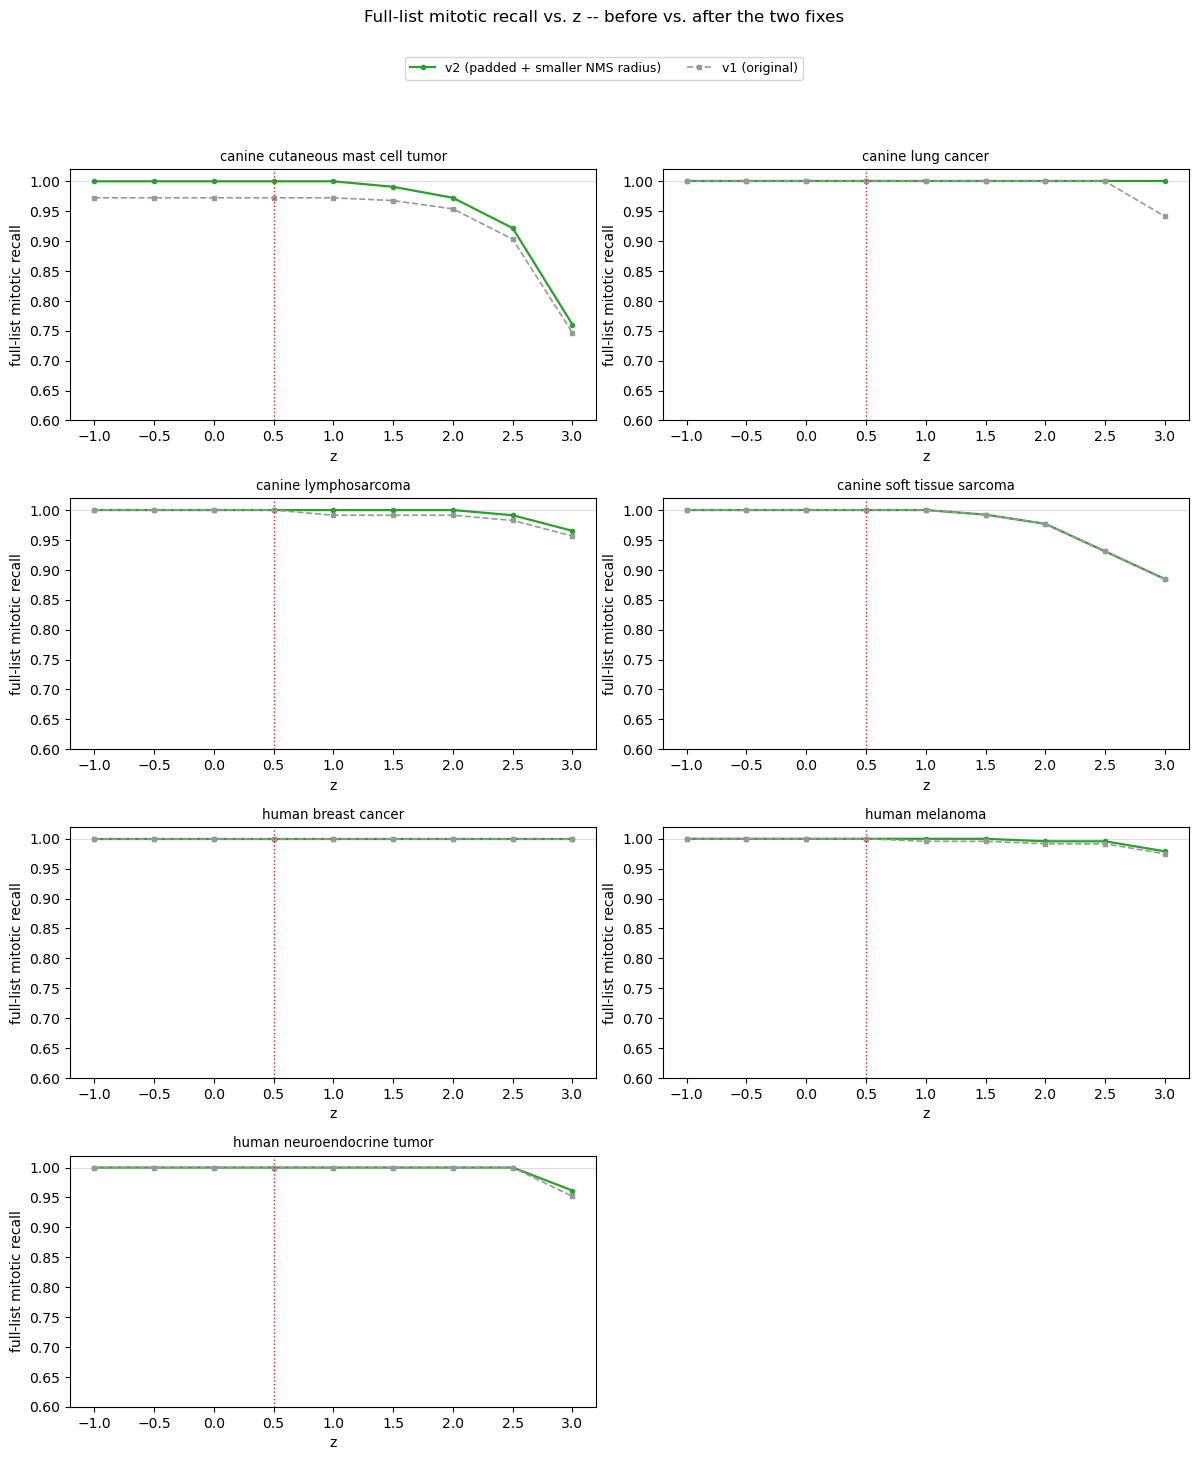

In [15]:
domains = sorted(recall_grid.index)
n = len(domains)
ncols = 2
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.4 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, domain in zip(axes, domains):
    ax.plot(recall_grid.columns, recall_grid.loc[domain], color='#2ca02c', marker='o',
           markersize=3, linewidth=1.6, label='v2 (padded + smaller NMS radius)')
    if domain in old_grid.index:
        ax.plot(old_grid.columns, old_grid.loc[domain], color='#999999', linestyle='--',
               marker='s', markersize=3, linewidth=1.2, label='v1 (original)')
    ax.axhline(1.0, color='#dddddd', linewidth=0.8, zorder=0)
    ax.axvline(CURRENT_Z, color='#d62728', linestyle=':', linewidth=1.0)
    ax.set_ylim(0.60, 1.02)
    ax.set_title(domain, fontsize=9.5)
    ax.set_xlabel('z')
    ax.set_ylabel('full-list mitotic recall')

for ax in axes[n:]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.04), fontsize=9)
fig.suptitle('Full-list mitotic recall vs. z -- before vs. after the two fixes', y=1.07, fontsize=12)
fig.tight_layout()
plt.show()

## Summary

Both fixes were checked rather than assumed: `valid.all()` was proven true by construction from
`PAD`'s definition and confirmed on every domain; the one-match-many-`z` shortcut was
re-verified at the new NMS radius rather than carried over; and the NMS-radius diagnosis was
traced through the actual suppression order on named annotations, which also settles the leak
accounting at **1 border + 5 NMS = 6** (not 2 + 5).

**Three things this notebook originally over-claimed, now corrected:**

* **`assert_floor_not_limiting` is not evidence about this run.** With
  `DEEP_FLOOR_Z = min(Z_LEVELS) - 0.5`, `cut < deep_floor` is impossible for every swept `z`,
  so it cannot fail here. It is insurance against future config drift; it was previously listed
  among the things "verified, not assumed", which reads as a check that could have caught
  something.
* **Full recall at `z <= 1.0` is coverage-saturated** (88.1-99.8% of arbitrary ROI locations are
  already within a match radius of some detection). What the fixes earned is the two named
  mechanisms, not the aggregate number. See the coverage grid.
* **The cost table was corrupted by this notebook's own `od` NaN bug** and is corrected above.

**And one limitation that is not fixable by editing:** one ROI per domain, `SEED_INDEX = 0`
only. `compare.summarise`'s docstring: *"Never report a single-seed number (Step 0 rule 5)."*
On these exact ROIs with this method, `read_95` has a seed-to-seed SD of 260-2744 candidates
(`results/tm_ccoeff_headtohead_seed_variance.csv`), and seed 0 sits on the **maximum** of the
five-seed distribution for `301.tiff` and the **minimum** for `246.tiff` and `548.tiff`. Every
per-domain reading-depth delta in the table above is smaller than that. The recall grid and the
`valid`/shortcut checks do not depend on the seed draw; the reading-depth deltas do.
